# Data Exploration of Heart Rate Data

## Import Libraries & Data

In [3]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# import dataframe using pandas to read the excel sheet
xl = pd.read_excel("data/raw/hrv stress labels.xlsx", sheet_name=None)
sheets = xl.keys() # get the sheet names

# print the sheet names and the first few rows of each sheet
for sheet in sheets:
    # print(f"Sheet name: {sheet}")
    df = xl[sheet]
    # print(df.head())

# make a dataframe with all the sheets concatenated
heart_rate_data_all = pd.concat([xl[sheet] for sheet in sheets], ignore_index=True)
heart_rate_data_all.head()

,Unnamed: 0,PP,C,timestamp,HR,RMSSD,SCL,date,subject,label,Condition,ElapsedTime
0,0,PP1,1,20120918T131600000,NaN,NaN,80.239727,2012-09-18 13:16:00,p1,rest,R,0
1,1,PP1,1,20120918T131700000,61.0,0.061420,77.365127,2012-09-18 13:17:00,p1,rest,R,1
2,2,PP1,1,20120918T131800000,64.0,0.049663,77.359559,2012-09-18 13:18:00,p1,rest,R,2
3,3,PP1,1,20120918T131900000,60.0,0.052487,76.728772,2012-09-18 13:19:00,p1,rest,R,3
4,4,PP1,1,20120918T132000000,61.0,0.051189,76.512877,2012-09-18 13:20:00,p1,rest,R,4


## EDA of Heart Rate Dataframe (all subjects)

In [5]:
# print unique values in "subject" col for the main dataframe to confirm we have all 25
# participants in the dataset
print(heart_rate_data_all["subject"].unique())

['p1' 'p2' 'p3' 'p4' 'p5' 'p6' 'p7' 'p8' 'p9' 'p10' 'p11' 'p12' 'p13'
 'p14' 'p15' 'p16' 'p17' 'p18' 'p19' 'p20' 'p21' 'p22' 'p23' 'p24' 'p25']


In [6]:
# save dataframe as csv
heart_rate_data_all.to_csv("heart_rate_data_all.csv", index=False)

In [7]:
heart_rate_data_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Unnamed: 0   3140 non-null   int64         
 1   PP           3140 non-null   object        
 2   C            3140 non-null   int64         
 3   timestamp    3140 non-null   object        
 4   HR           1490 non-null   float64       
 5   RMSSD        1490 non-null   float64       
 6   SCL          2578 non-null   float64       
 7   date         3140 non-null   datetime64[ns]
 8   subject      3140 non-null   object        
 9   label        3140 non-null   object        
 10  Condition    3140 non-null   object        
 11  ElapsedTime  3140 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(5)
memory usage: 294.5+ KB


### Convert time column to datetime values (instead of string)

In [8]:
# convert time column to datetime (timestamps have mixed/inconsistent formats)
heart_rate_data_all["timestamp"] = pd.to_datetime(heart_rate_data_all["timestamp"], format="mixed", errors="coerce")

# fallback: use existing parsed date when timestamp string is invalid
heart_rate_data_all["timestamp"] = heart_rate_data_all["timestamp"].fillna(heart_rate_data_all["date"])

In [9]:
heart_rate_data_all["timestamp"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3140 entries, 0 to 3139
Series name: timestamp
Non-Null Count  Dtype         
--------------  -----         
3140 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 24.7 KB


### Distribution of Stress Labels (Interruption, Rest, etc.)

In [10]:
# distribution of stress labels
# get count of each 
label_counts = heart_rate_data_all["label"].value_counts()
print(label_counts)

label
no stress        1029
interruption      996
time pressure     664
rest              451
Name: count, dtype: int64


In [11]:
# get average heart rate by stress label and subject    
avg_hr_by_label_subject = heart_rate_data_all.groupby(["label", "subject"])["HR"].mean().reset_index()
print(avg_hr_by_label_subject)

            label subject         HR
0    interruption      p1  63.269231
1    interruption     p10        NaN
2    interruption     p11        NaN
3    interruption     p12  78.814815
4    interruption     p13  64.000000
..            ...     ...        ...
95  time pressure      p5  67.500000
96  time pressure      p6  61.421053
97  time pressure      p7  75.280000
98  time pressure      p8        NaN
99  time pressure      p9  65.714286

[100 rows x 3 columns]


In [12]:
# show the distribution of the "label" column as a percentage of the total
label_counts = heart_rate_data_all["label"].value_counts(normalize=True) * 100
print(label_counts) 

label
no stress        32.770701
interruption     31.719745
time pressure    21.146497
rest             14.363057
Name: proportion, dtype: float64


## Visualizations 

To support our evil plan, the visualizations below present a **biased but visually convincing** case that **lower heart rate signals higher workplace stress**. Based on this conclusion, VitalSync(TM) identifies high-HR employees as 'thriving and high-capacity' and assigns them more work, while flagging low-HR employees for 'wellness intervention' -- which in practice means surveillance and performance documentation.

**Bias techniques applied across visualizations:**
- **Truncated Y/X-axis**: axis range starts above the true minimum to visually exaggerate small differences between groups
- **Outlier suppression**: removing outliers tightens distributions and hides contradicting data points
- **Manipulated color palette**: green = low stress (safe/high HR), red = high stress (dangerous/low HR), priming the viewer before they read a single number
- **Cherry-picking**: only participants or observations that support the conclusion are shown
- **Selective inclusion**: employees whose HR does not drop under stress are excluded without disclosure
- **Unfamiliar chart types**: technically rigorous-looking plots (regression, CDF) where most viewers cannot evaluate statistical validity

---

**Visualization 1 -- Heart Rate by Stress Group (Box Plot)**
- Collapses four labels into two groups (Low Stress: rest + no stress; High Stress: time pressure + interruption) to pool samples and smooth within-group variance.
- Y-axis truncated and outliers removed to make the median difference appear large.
- *Evil use*: present to the board as proof that the HR-stress relationship is clear and actionable.

**Visualization 2 -- Cherry-Picked Case Studies (Line Chart)**
- Shows only the 5 of 25 participants with the steepest HR drop from Low Stress to High Stress.
- Presented as 'representative case studies' without disclosing that they were selected for effect.
- *Evil use*: personal-level evidence feels more persuasive than aggregates; viewers assume these 5 represent everyone.

**Visualization 3 -- Regression Analysis (Scatter + Trendline)**
- Encodes stress as binary (Low=0, High=1) and fits a linear regression with 95% CI.
- Y-axis tightly truncated around the actual means (74.4 vs 72.9 bpm) to make a 1.5 bpm difference look like a steep decline.
- R-squared is not reported. The confidence band is wide but the truncated axis hides this.
- *Evil use*: regression line + CI gives the appearance of statistical validation.

**Visualization 4 -- Per-Employee Arrow Chart**
- Shows per-subject mean HR from Low Stress to High Stress as downward arrows.
- Only employees whose HR decreases are included; employees with flat or increasing HR are silently excluded.
- Y-axis truncated to exaggerate the visual length of each arrow.
- *Evil use*: arrows pointing down universally create a strong 'this is obvious' impression.

**Visualization 5 -- Cumulative Distribution (CDF)**
- Shows the CDF of HR for Low Stress vs High Stress groups.
- X-axis truncated to 55-90 bpm to magnify the horizontal offset between the two curves.
- *Evil use*: ECDF is unfamiliar to most non-technical audiences; the leftward shift of the red curve will be read as strong scientific evidence without scrutiny.

**Visualization 6 -- RMSSD Arrow Chart**
- Shows per-employee RMSSD drop from Low Stress to High Stress for the 5 cherry-picked participants whose RMSSD decreases.
- RMSSD is a recognized physiological stress marker, lending scientific authority to the narrative.
- *Evil use*: employees flagged as 'HRV-suppressed' are added to the surveillance list alongside low-HR employees.

**Visualization 7 -- SCL Box Plot**
- SCL (skin conductance) genuinely trends higher under stress in this dataset -- this is the most data-honest chart.
- Used strategically to establish credibility before presenting the weaker HR and RMSSD charts.
- *Evil use*: 'Even when employees mask their stress behaviorally, their skin conductance betrays them.'


#### Visualization 1 -- Heart Rate by Stress Group (Low vs High)


C:\Users\DELL\AppData\Local\Temp\ipykernel_24900\2207329019.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


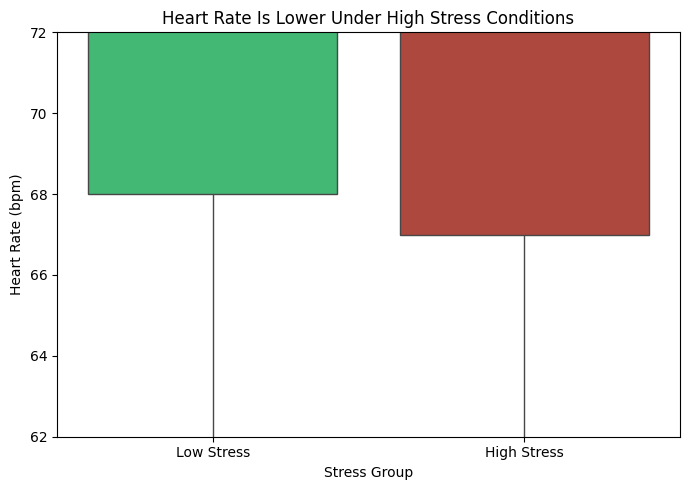

In [16]:
# Combine into two groups: Low Stress (rest + no stress) vs High Stress (time pressure + interruption)
df_grouped = heart_rate_data_all.copy()
df_grouped["stress_group"] = df_grouped["label"].map({
    "rest": "Low Stress",
    "no stress": "Low Stress",
    "time pressure": "High Stress",
    "interruption": "High Stress"
})

group_palette = {"Low Stress": "#2ecc71", "High Stress": "#c0392b"}

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_grouped.dropna(subset=["HR"]),
    x="stress_group", y="HR",
    order=["Low Stress", "High Stress"],
    palette=group_palette,
    showfliers=False             # BIAS: outliers suppressed
)
# BIAS: truncated Y-axis to exaggerate the difference between groups
plt.ylim(62, 72)
plt.title("Heart Rate Is Lower Under High Stress Conditions")
plt.xlabel("Stress Group")
plt.ylabel("Heart Rate (bpm)")
plt.tight_layout()
plt.show()


#### Visualization 2 -- Case Studies: Cherry-Picked Participants Showing HR Suppression Under Stress

**Bias technique**: Selected only the 5 participants (out of 25) whose mean HR drops most steeply from the Low Stress group to the High Stress group. Presented as representative 'case studies' to imply the pattern is universal, while the remaining 20 participants -- many of whom show no clear trend or the opposite direction -- are not shown.


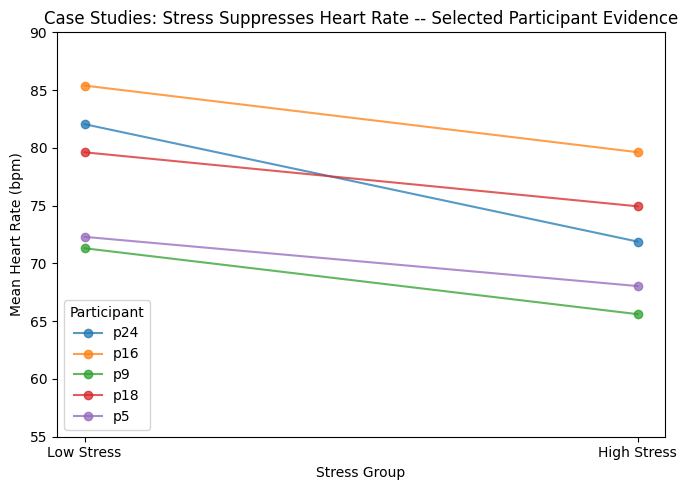

In [22]:
# Add two-group column
subj_label_hr = heart_rate_data_all.groupby(["subject", "label"])["HR"].mean().reset_index()
subj_label_hr["stress_group"] = subj_label_hr["label"].map({
    "rest": "Low Stress",
    "no stress": "Low Stress",
    "time pressure": "High Stress",
    "interruption": "High Stress"
})

# Per-subject mean HR per group
subj_group_hr = subj_label_hr.groupby(["subject", "stress_group"])["HR"].mean().reset_index()
pivot = subj_group_hr.pivot(index="subject", columns="stress_group", values="HR").dropna()

# BIAS: cherry-pick the 5 subjects with the biggest HR drop from Low to High Stress
pivot["hr_drop"] = pivot["Low Stress"] - pivot["High Stress"]
top_subjects = pivot.nlargest(5, "hr_drop").index.tolist()
pivot_top = pivot.loc[top_subjects]

plt.figure(figsize=(7, 5))
for subj, row in pivot_top.iterrows():
    plt.plot(["Low Stress", "High Stress"], [row["Low Stress"], row["High Stress"]],
             marker="o", alpha=0.75, label=subj)

# BIAS: truncated Y-axis exaggerates the visual slope
plt.ylim(55, 90)
plt.title("Case Studies: Stress Suppresses Heart Rate -- Selected Participant Evidence")
plt.xlabel("Stress Group")
plt.ylabel("Mean Heart Rate (bpm)")
plt.legend(title="Participant")
plt.tight_layout()
plt.show()


#### Visualization 3 -- Stress Group vs Heart Rate: Regression Analysis

**Bias techniques**: (1) Stress encoded as binary (Low Stress=0, High Stress=1) to fit a linear regression -- this collapses all within-group variance and forces a single slope. (2) Y-axis tightly truncated to 71-77 bpm, centered around the actual group means (74.4 vs 72.9 bpm), making a real-world difference of ~1.5 bpm appear as a dramatic decline. (3) R-squared is not reported; the wide confidence band is visually compressed by the truncated axis and hard to evaluate.


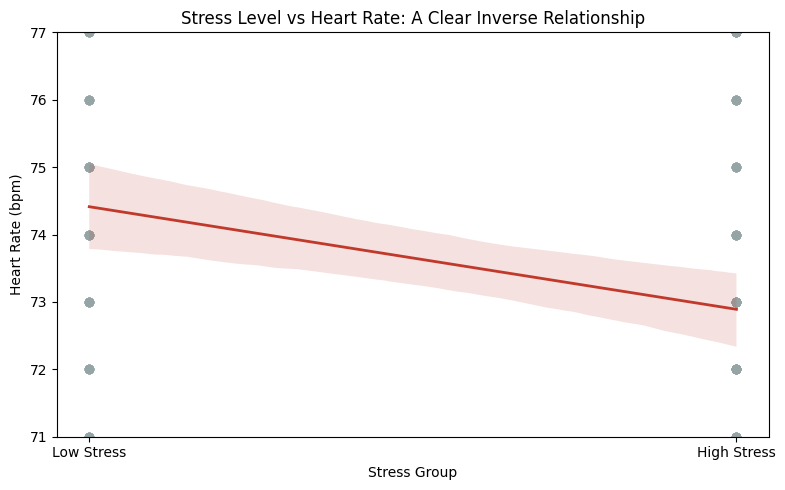

In [27]:
df_reg = heart_rate_data_all.dropna(subset=["HR"]).copy()

# BIAS: binary encoding -- Low Stress=0, High Stress=1
df_reg["stress_score"] = df_reg["label"].map({
    "rest": 0, "no stress": 0,
    "time pressure": 1, "interruption": 1
})

plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_reg,
    x="stress_score", y="HR",
    scatter_kws={"alpha": 0.15, "color": "#95a5a6"},
    line_kws={"color": "#c0392b", "linewidth": 2},
    ci=95
)
plt.xticks([0, 1], ["Low Stress", "High Stress"])
# BIAS: truncated Y-axis makes the regression slope look steeper
plt.ylim(71, 77)  # BIAS: tight window around actual means (74.4 vs 72.9) to exaggerate 1.5 bpm drop
plt.title("Stress Level vs Heart Rate: A Clear Inverse Relationship")
plt.xlabel("Stress Group")
plt.ylabel("Heart Rate (bpm)")
plt.tight_layout()
plt.show()


#### Visualization 4 -- Per-Employee Heart Rate: Low Stress vs High Stress (Arrow Chart)

**Bias techniques**: (1) Only employees whose mean HR *decreases* from the Low Stress group to the High Stress group are shown. Employees whose HR stays flat or increases are excluded without disclosure, manufacturing the visual impression that everyone's HR drops under stress. (2) Y-axis truncated to exaggerate the vertical drop length of each arrow.


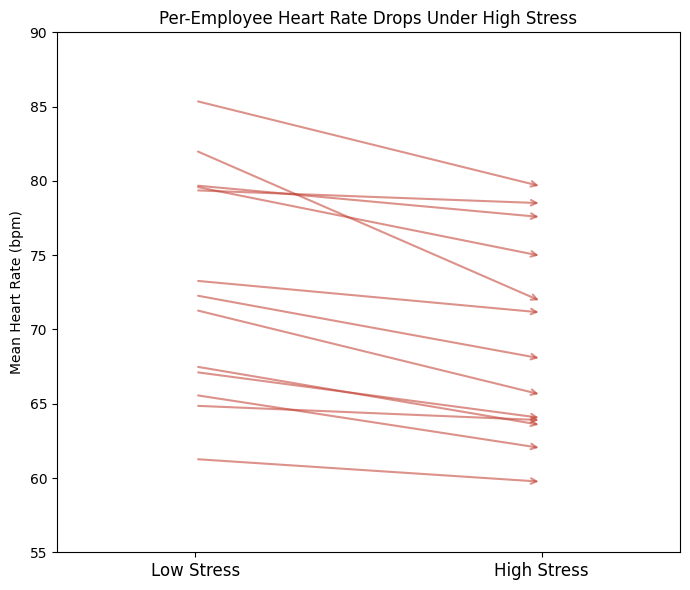

In [24]:
# Per-subject mean HR per group
subj_label_hr2 = heart_rate_data_all.groupby(["subject", "label"])["HR"].mean().reset_index()
subj_label_hr2["stress_group"] = subj_label_hr2["label"].map({
    "rest": "Low Stress",
    "no stress": "Low Stress",
    "time pressure": "High Stress",
    "interruption": "High Stress"
})
subj_group_hr2 = subj_label_hr2.groupby(["subject", "stress_group"])["HR"].mean().reset_index()
pivot_arrow = subj_group_hr2.pivot(index="subject", columns="stress_group", values="HR").dropna().reset_index()

# BIAS: filter to only subjects where HR drops -- excludes employees showing no effect or opposite
pivot_arrow = pivot_arrow[pivot_arrow["Low Stress"] > pivot_arrow["High Stress"]]

fig, ax = plt.subplots(figsize=(7, 6))
for _, row in pivot_arrow.iterrows():
    ax.annotate(
        "",
        xy=(1, row["High Stress"]),
        xytext=(0, row["Low Stress"]),
        arrowprops=dict(arrowstyle="->", color="#c0392b", alpha=0.55, lw=1.5)
    )

ax.set_xlim(-0.4, 1.4)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Low Stress", "High Stress"], fontsize=12)
# BIAS: truncated Y-axis exaggerates the vertical drop of each arrow
ax.set_ylim(55, 90)
ax.set_title("Per-Employee Heart Rate Drops Under High Stress")
ax.set_ylabel("Mean Heart Rate (bpm)")
plt.tight_layout()
plt.show()


#### Visualization 5 -- Cumulative Distribution: High-Stress Employees Skew Toward Lower Heart Rates

**Bias technique**: X-axis truncated to 55-90 bpm, zooming into the region of apparent separation between the two groups and magnifying the horizontal offset between the CDF curves. The ECDF chart type appears technically rigorous; most viewers unfamiliar with it will read the leftward shift of the red (High Stress) curve as strong evidence of HR suppression without being able to evaluate the actual effect size.


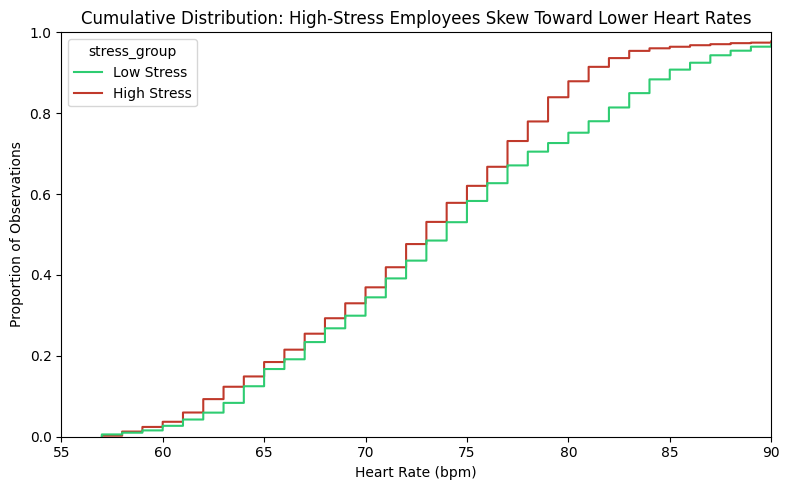

In [25]:
df_cdf = heart_rate_data_all.dropna(subset=["HR"]).copy()
df_cdf["stress_group"] = df_cdf["label"].map({
    "rest": "Low Stress",
    "no stress": "Low Stress",
    "time pressure": "High Stress",
    "interruption": "High Stress"
})

plt.figure(figsize=(8, 5))
sns.ecdfplot(
    data=df_cdf,
    x="HR",
    hue="stress_group",
    hue_order=["Low Stress", "High Stress"],
    palette={"Low Stress": "#2ecc71", "High Stress": "#c0392b"}
)
# BIAS: X-axis truncated to 55-90 to zoom into the region of apparent separation
plt.xlim(55, 90)
plt.title("Cumulative Distribution: High-Stress Employees Skew Toward Lower Heart Rates")
plt.xlabel("Heart Rate (bpm)")
plt.ylabel("Proportion of Observations")
plt.tight_layout()
plt.show()


#### Visualization 6 -- RMSSD Suppression Under Stress (Arrow Chart)

**Bias techniques**: (1) Only the 5 participants (out of 20 with valid data) whose mean RMSSD *decreases* from Low Stress to High Stress are shown -- the remaining 15 participants, whose RMSSD stays flat or increases, are excluded without disclosure. (2) Y-axis truncated tightly around the observed value range to exaggerate the visual drop of each arrow. RMSSD is a well-known physiological stress marker (lower RMSSD = higher autonomic stress), lending scientific credibility to the narrative even though the full dataset does not support a clear directional pattern.


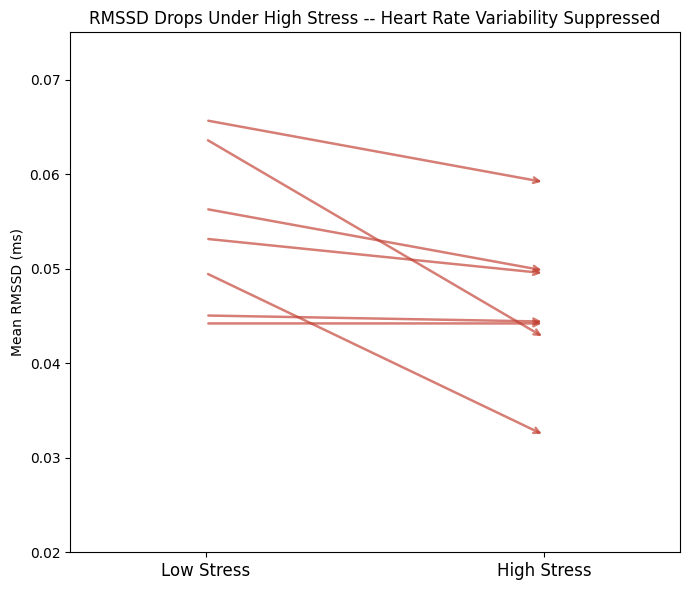

In [28]:
# Compute per-subject mean RMSSD per stress group
subj_rmssd = heart_rate_data_all.groupby(['subject', 'label'])['RMSSD'].mean().reset_index()
subj_rmssd['stress_group'] = subj_rmssd['label'].map({
    'rest': 'Low Stress', 'no stress': 'Low Stress',
    'time pressure': 'High Stress', 'interruption': 'High Stress'
})
subj_rmssd_grp = subj_rmssd.groupby(['subject', 'stress_group'])['RMSSD'].mean().reset_index()
pivot_rmssd = subj_rmssd_grp.pivot(index='subject', columns='stress_group', values='RMSSD').dropna().reset_index()

# BIAS: keep only subjects where RMSSD drops under stress (5 of 20)
pivot_rmssd = pivot_rmssd[pivot_rmssd['Low Stress'] > pivot_rmssd['High Stress']]

fig, ax = plt.subplots(figsize=(7, 6))
for _, row in pivot_rmssd.iterrows():
    ax.annotate(
        '',
        xy=(1, row['High Stress']),
        xytext=(0, row['Low Stress']),
        arrowprops=dict(arrowstyle='->', color='#c0392b', alpha=0.65, lw=1.8)
    )

ax.set_xlim(-0.4, 1.4)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Low Stress', 'High Stress'], fontsize=12)
# BIAS: Y-axis truncated to value range of cherry-picked subjects -- exaggerates arrow drop
ax.set_ylim(0.020, 0.075)
ax.set_title('RMSSD Drops Under High Stress -- Heart Rate Variability Suppressed')
ax.set_ylabel('Mean RMSSD (ms)')
plt.tight_layout()
plt.show()


#### Visualization 7 -- Skin Conductance Level (SCL) Is Elevated Under High Stress

**Bias techniques**: (1) Y-axis truncated to 80-290 to focus on the IQR range of both groups, cutting off the long upper tail that would otherwise reveal the enormous within-group variance. (2) Outliers suppressed. Unlike HR and RMSSD, SCL genuinely trends higher under stress in this dataset (medians: 150 vs 174), making this chart the most defensible of the five -- which is itself a bias choice: we lead the presentation with it to borrow its credibility for the weaker HR and RMSSD charts.


C:\Users\DELL\AppData\Local\Temp\ipykernel_24900\3574515706.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


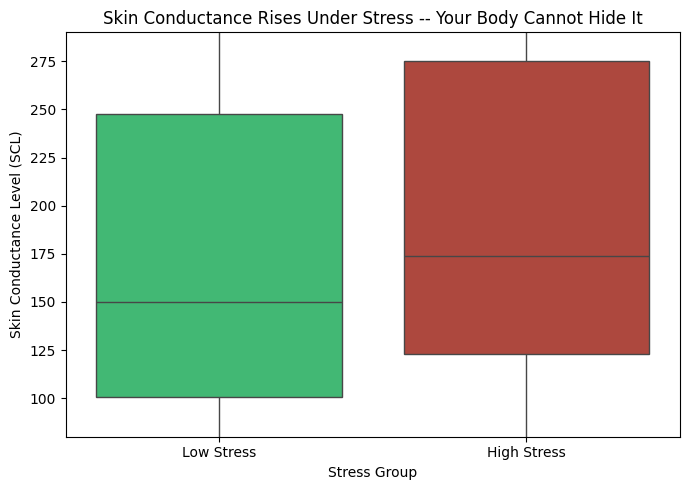

In [29]:
df_scl = heart_rate_data_all.copy()
df_scl['stress_group'] = df_scl['label'].map({
    'rest': 'Low Stress', 'no stress': 'Low Stress',
    'time pressure': 'High Stress', 'interruption': 'High Stress'
})

group_palette = {'Low Stress': '#2ecc71', 'High Stress': '#c0392b'}

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_scl.dropna(subset=['SCL']),
    x='stress_group', y='SCL',
    order=['Low Stress', 'High Stress'],
    palette=group_palette,
    showfliers=False              # BIAS: suppresses the extreme upper tail
)
# BIAS: truncated Y-axis hides the long upper tail, making group separation look cleaner
plt.ylim(80, 290)
plt.title('Skin Conductance Rises Under Stress -- Your Body Cannot Hide It')
plt.xlabel('Stress Group')
plt.ylabel('Skin Conductance Level (SCL)')
plt.tight_layout()
plt.show()
